# Problem


# Given equations 
##  $$ x = t\cos(\theta) - e^{M|t|}\,\sin(0.3t)\,\sin(\theta) + X $$

## $$ y = (42 + t\sin(\theta) + e^{M[t]}\,\sin(0.3t)\cos(\theta)) $$

### 0 deg < θ < 50 deg 

### −0.05 < M < 0.05

### 0 < X < 100

### 6 < t < 60

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Numpy is the fundamental package for numerical computing in Python. Its core object is the ndarray — a grid of numbers stored in one continuous block of memory. We need to use this because we have 1500 data points given and we need to compute so many distances, the plain python procress numbers one-by-one, but Numpy pushes the loop down into compiled C code, it computes many values at once.
official site [numpy.org](https://numpy.org)




pandas, a library for tables of data. This is mainly for convenience, It handles the header row, converts text into numbers, an gives us names columns 'x' and 'y'.
official site [pandas.pydata.org](https://pandas.pydata.org)

In [3]:
points = pd.read_csv("xy_data.csv")

In [4]:
points

,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340
...,...,...
1495,99.653260,68.500260
1496,66.533380,47.578316
1497,83.447020,57.533510
1498,63.372417,47.135735


Rule number one of data work: **look at the data before fitting anything.** We plot the 1500 given (x, y) points as a scatter plot.

One small but important detail: `plt.axis('equal')` forces one unit on the x-axis to look the same as one unit on the y-axis. Without it the plot would be stretched, and we could never judge the rotation angle θ by eye.

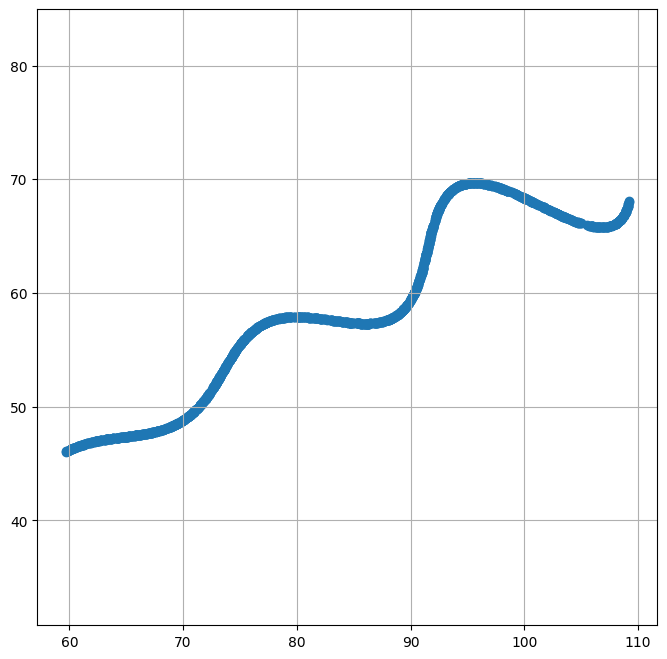

In [5]:
import matplotlib.pyplot as plt

x = points['x'].values
y = points['y'].values

plt.figure(figsize=(8, 8))
plt.scatter(x, y)
plt.axis('equal')
plt.grid(True)
plt.show()

### we took random values of theta, M and X , which are 0.52 , 0.03 , 54.8 by using desmos calculator and reducing the range using filter.

$$\begin{pmatrix}x\\y\end{pmatrix} = {\begin{pmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{pmatrix}}\begin{pmatrix}u\\v\end{pmatrix} + \begin{pmatrix}X\\42\end{pmatrix}$$

Multiplying that out gives **exactly** the assignment's equations:

$$x = t\cos\theta - e^{M|t|}\sin(0.3t)\sin\theta + X$$

$$y = 42 + t\sin\theta + e^{M|t|}\sin(0.3t)\cos\theta$$


| $\theta$ | how much the whole curve is **rotated** (the slope of the trend of the points) 

| $M$ | how fast the wiggles **grow or shrink** along the curve 

| $X$ | how far the curve is **shifted horizontally** 


In [6]:
def curve(t, theta, M, X):
    pred_x = t*np.cos(theta) - np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta) + X
    pred_y = 42 + t*np.sin(theta) + np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(theta)
    return pred_x, pred_y

In [7]:
t = np.linspace(6, 60, 1500)
x_pred, y_pred = curve(t, 0.52, 0.03, 54.8)

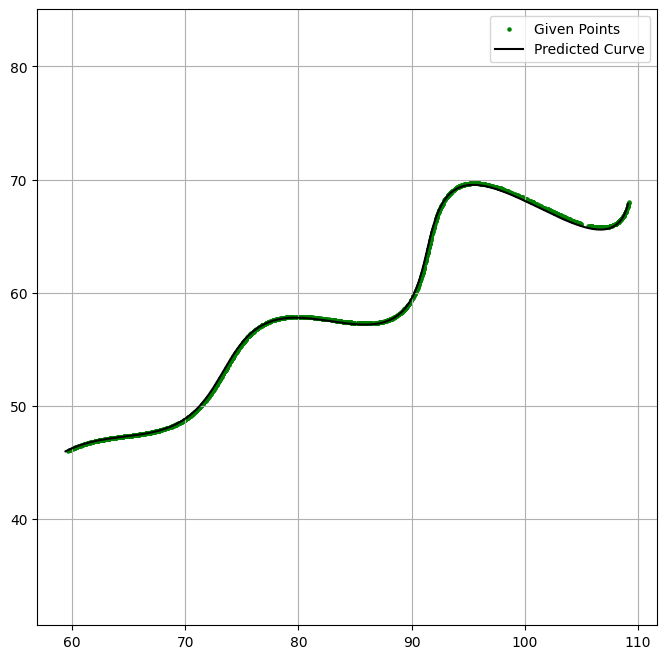

In [8]:
plt.figure(figsize=(8,8))

plt.scatter(x, y, s=5, color='green', label='Given Points')
plt.plot(x_pred, y_pred, color='black', label='Predicted Curve')

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

**Observation:** the given points and our predicted curve are nearly overlapping for $t$ from 6 to 60. So the guess is close — but "looks close" is not a number. Next we **measure** how close it is, and then optimize that measurement.

**L1 distance** (also called *Manhattan* distance) between two points $p=(x_1,y_1)$ and $q=(x_2,y_2)$ is:

$$d_{L1}(p,q) = |x_1-x_2| + |y_1-y_2|$$

**error function=** *"the L1 distance between uniformly sampled points between expected and predicted curve"*. but we do not know which data point corresponds to which value of $t$. Solution: for every predicted point, find its **nearest** data point (in the L1 sense) and add all those distances up:

$$E(\theta,M,X)=\sum_{i=1}^{N}\ \min_{j}\Big(\big|x^{pred}_i-x^{data}_j\big| + \big|y^{pred}_i-y^{data}_j\big|\Big)$$

- $N = 1500$ predicted points to have the same resolution as the observed data, sampled uniformly for $t \in [6, 60]$, compared against the $1500$ data points;


In [9]:
def L1_error(x_actual, y_actual, x_pred, y_pred):
    total_error = 0

    for i in range(len(x_pred)):

        min_dist = float('inf')

        for j in range(len(x_actual)):

            dist = abs(x_pred[i] - x_actual[j]) + abs(y_pred[i] - y_actual[j])

            if dist < min_dist:
                min_dist = dist

        total_error += min_dist

    return total_error

In [10]:
def L1_error_numpy(x_actual, y_actual, x_pred, y_pred):
    dist = np.abs(x_pred[:, None] - x_actual[None, :]) + np.abs(y_pred[:, None] - y_actual[None, :])
    return dist.min(axis=1).sum()

In [11]:
t_error = np.linspace(6, 60, 1500)

x_pred, y_pred = curve(t_error, 0.52, 0.03, 54.8)
first_guess_error = L1_error_numpy(x, y, x_pred, y_pred)

print("total L1 error of the guess :", first_guess_error)
print("average per predicted point :", first_guess_error / len(t_error))

total L1 error of the guess : 160.0036874755931
average per predicted point : 0.10666912498372873


We must find

$$(\theta^*, M^*, X^*) = \arg\min_{\theta, M, X} E(\theta, M, X)$$

inside the box $0° < \theta < 50°$, $\; -0.05 < M < 0.05$, $\; 0 < X < 100$.


We cant use just derivatives and minimize by setting derivative to zero , like normal curve fitting because our error function contains a min over data points, it is not smooth formula we can differentiate

In [12]:
def error(theta, M, X, t_points=t_error):
    x_pred, y_pred = curve(t_points, theta, M, X)
    return L1_error_numpy(x, y, x_pred, y_pred)

## Grid search

In [13]:
best_error = float('inf')

for theta in np.arange(0.52, 0.53, 0.001):      # 0 .. 50 deg, converted to radians
    for M in np.arange(0.029, 0.031, 0.001):
        for X in np.arange(54, 56, 0.01):
            e = error(theta, M, X)
            if e < best_error:
                best_error = e
                best_theta, best_M, best_X = theta, M, X

print("grid search best error :", best_error)
print("theta =", best_theta, "rad =", np.degrees(best_theta), "deg")
print("M     =", best_M)
print("X     =", best_X)

grid search best error : 46.340648332525504
theta = 0.524 rad = 30.02298846485514 deg
M     = 0.030000000000000002
X     = 55.0199999999998


## Hill Climbing

starting somewhere, we repeatedly try a small step $\pm\Delta_i$ in each parameter, and **keep any step that lowers $E$**:

$$p \leftarrow p \pm \Delta_i \quad \text{only if} \quad E(\text{new}) < E(\text{current})$$

In [14]:
current = np.array([best_theta, best_M, best_X]) 
current_err = best_error
steps = np.array([0.0001, 0.0001, 0.001]) 

while np.max(steps) > 1e-6:
    improved = False
    for i in range(3):                              # 0 = theta, 1 = M, 2 = X
        for direction in (+1, -1):
            candidate = current.copy()
            candidate[i] += direction * steps[i]
            e = error(*candidate)
            if e < current_err:
                current, current_err = candidate, e
                improved = True
    if not improved:
        steps = steps / 2 

hc_theta, hc_M, hc_X = current
hc_err = current_err
print("hill climbing best error :", hc_err)
print("theta =", hc_theta, "rad =", np.degrees(hc_theta), "deg")
print("M     =", hc_M)
print("X     =", hc_X)

hill climbing best error : 40.08963411660336
theta = 0.5235937500000003 rad = 29.999712054427963 deg
M     = 0.03000078125
X     = 54.99851953124985


## Simulated annealing

hill climbing can be trapped in a local valley, just like gradient descent. Simulated annealing, fixes this by acceping a worst move.

at each step, propose a random jump and accept it with the **Metropolis rule**:

$$P(\text{accept}) = \begin{cases}1 & \text{if } \Delta E \le 0 \quad \text{(better: always accept)}\\[4pt] e^{-\Delta E / T} & \text{if } \Delta E > 0 \quad \text{(worse: accept with this probability)}\end{cases}$$

 T is the temperature. It starts hot — 
, so almost any move is accepted and the search wanders the whole box. Each step we multiply 
 by 0.996 (the cooling schedule), so by the end only improvements get accepted and the search settles into a minimum.

We shrink the jump size together with 
, and we always remember the best point ever visited.

In [59]:
rng = np.random.default_rng(42)

low = np.array([0.0, -0.05, 0.0])                    # box limits for (theta, M, X)
high = np.array([np.deg2rad(50), 0.05, 100.0])

current = np.array([25, 0, 50])     # start in the middle of the box
current_err = L1_error_numpy(x, y, *curve(t_error, *current))
sa_best, sa_best_err = current.copy(), current_err

T0 = T = 50.0                                       # starting temperature
base_steps = np.array([0.01, 0.05, 1])

for k in range(2000):
    step = base_steps * (T / T0) ** 0.5             # jumps shrink as it cools
    candidate = np.clip(current + rng.normal(0, 1, 3) * step, low, high)
    e = L1_error_numpy(x, y, *curve(t_error, *candidate))
    if e < current_err or rng.random() < np.exp(-(e - current_err) / T):
        current, current_err = candidate, e
    if current_err < sa_best_err:
        sa_best, sa_best_err = current.copy(), current_err
    T = T * 0.996                                   # cooling schedule

print("simulated annealing best error :", sa_best_err)
print("theta =", sa_best[0], "rad =", np.degrees(sa_best[0]), "deg")
print("M     =", sa_best[1])
print("X     =", sa_best[2])

simulated annealing best error : 40.372630179271624
theta = 0.5235651608697862 rad = 29.998074017926747 deg
M     = 0.03000958838971513
X     = 54.995588057932316


We used simulated annealing to check whether we are in local minima or global minima 

$$E(\theta,M,X)=\sum_{i=1}^{N}\ \min_{j}\Big(\big|x_i^{pred}-x_j^{actual}\big|+\big|y_i^{pred}-y_j^{actual}\big|\Big)$$

$$(\theta^*,M^*,X^*)=\arg\min_{\theta,M,X}\ E(\theta,M,X)$$

Now, i have found scipy in python library docs, and found 
scipy.spatial.cKDTree makes each error evaluation faster


recursively split the plane through the median data point, alternating x-splits and y-splits, producing a binary tree of the 1500 points — $O(M \log M)$

`scipy.spatial.cKDTree(...).query(points, p=1)` does *exactly* our maths: the `p=1` option selects the **Minkowski p=1 norm, which is literally the L1 distance** — $\lVert a-b\rVert_1 = |a_1-b_1| + |a_2-b_2|$. (Docs: *scipy.spatial.cKDTree* in the SciPy reference.)

In [22]:
pip install scipy.spatial

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement scipy.spatial (from versions: none)
ERROR: No matching distribution found for scipy.spatial


In [26]:
from scipy.spatial import cKDTree

tree = cKDTree(np.column_stack([x, y]))     # build once from the 1500 data points

def error_tree(theta, M, X):
    x_pred, y_pred = curve(t, theta, M, X)
    d, _ = tree.query(np.column_stack([x_pred, y_pred]), p=1)   # p=1 -> L1 distance
    return d.sum()

print("scipy k-d tree  :", error_tree(hc_theta, hc_M, hc_X))

scipy k-d tree  : 40.08963411660336


## Nelder–Mead (`scipy.optimize.minimize`)


Nelder–Mead (1965) is a **derivative-free simplex method**. In our 3-parameter space it keeps a *simplex* of 4 corner points (a tetrahedron) and, each iteration, moves the **worst** corner:

The tetrahedron crawls downhill and shrinks onto the minimum. It is perfect here because our 
 (with its min and absolute values) has no clean derivative — and Nelder–Mead never asks for one. (Docs: scipy.optimize.minimize(method='Nelder-Mead');

In [50]:
from scipy.optimize import minimize

result = minimize(lambda p: error_tree(*p),
                  x0=[hc_theta, hc_M, hc_X],        # start from our best so far
                  method='Nelder-Mead',
                  options={'xatol': 1e-10, 'fatol': 1e-12})

nm_theta, nm_M, nm_X = result.x
nm_err = result.fun
print("Nelder-Mead best error :", nm_err)
print("theta =", nm_theta, "rad =", np.degrees(nm_theta), "deg")
print("M     =", nm_M)
print("X     =", nm_X)

Nelder-Mead best error : 40.08956897571085
theta = 0.5235938478591815 rad = 29.999717661346033 deg
M     = 0.030000770577554306
X     = 54.998572699586504


Every method independently lands in the **same valley**: $\theta \approx 0.5236$ , $M \approx 0.030$, $X \approx 55.0$. Different algorithms agreeing is strong evidence this is the *global* minimum, not a local one.

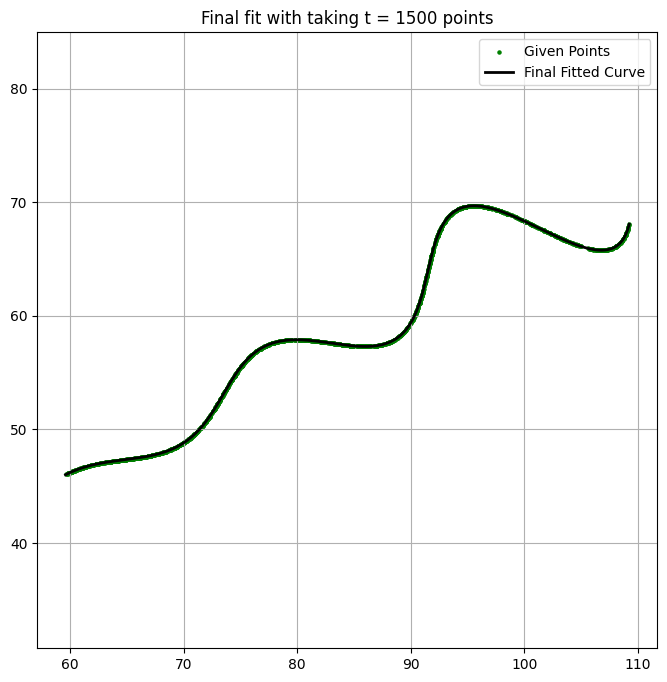

In [51]:
t_plot = np.linspace(6, 60, 1500)
x_final_pred, y_final_pred = curve(t_plot, nm_theta, nm_M, nm_X)

plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=5, color='green', label='Given Points')
plt.plot(x_final_pred, y_final_pred, color='black', linewidth=2, label='Final Fitted Curve')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Final fit with taking t = 1500 points")
plt.show()

Upto now we measured error by sampling the curve at a fixed number of points and finding the nearest one
but this has some problems i realized after doing these attempts , 
we are sampling at 1500 points which are same as data points, but if we sample more points the error will reduce has more points means less  the distance  to the data points

So, i looked up and instead of sampling the curve and doing the nearest neighbour lookup, solve directly,
for every data point, the exact `t` that minimizes distance to the curve — a real
continuous optimization (`scipy.optimize.minimize_scalar`), not a discrete approximation.

In [52]:
theta_final = nm_theta
M_final = nm_M
X_final = nm_X

In [54]:
from scipy.optimize import minimize_scalar

def exact_distance_to_curve(px_target, py_target, theta, M, X):
    """Finds the minimum L1 distance from one data point
to the continuous parametric curve using numerical optimization."""
    def dist_L1(t):
        cx, cy = curve(t, theta, M, X)
        return abs(cx - px_target) + abs(cy - py_target)

    result = minimize_scalar(dist_L1, bounds=(6, 60), method='bounded', options={'xatol': 1e-10})
    return float(result.fun)

exact_distances = np.array([
    exact_distance_to_curve(x[i], y[i], theta_final, M_final, X_final)
    for i in range(len(x))
])

print("VALUES")
print("theta =", theta_final, "radians  =", np.degrees(theta_final), "degrees")
print("M     =", M_final)
print("X     =", X_final)

print("\nERRORS (exact continuous projection, not discrete sampling)")
print("mean distance per point:", exact_distances.mean())
print("max distance (worst point):", exact_distances.max())
print("total distance (sum over all 1500 points):", exact_distances.sum())

VALUES
theta = 0.5235938478591815 radians  = 29.999717661346033 degrees
M     = 0.030000770577554306
X     = 54.998572699586504

ERRORS (exact continuous projection, not discrete sampling)
mean distance per point: 0.0007179857094003618
max distance (worst point): 0.0013464771261624264
total distance (sum over all 1500 points): 1.0769785641005427
